In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## step 1 :Import Libraries

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder, OneHotEncoder, RobustScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor,RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

import pickle

import warnings
warnings.filterwarnings("ignore")


## step 2 :Load the dataset

In [181]:
car_df = pd.read_csv("/content/drive/MyDrive/ML_Projects/car_price_prediction.csv")
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

## Car Price Prediction Dataset – Columns
- **ID – Unique number for each car record (not useful for prediction).**

- **Levy – Additional tax/fee applied to the car price.**

- **Manufacturer – Brand/company of the car (Toyota, BMW, etc.).**

- **Model – Specific car model name.**

- **Prod. year – Year the car was manufactured.**

- **Category – Type/body style of the car (Sedan, SUV, Hatchback, etc.).**

- **Leather interior – Indicates whether the car has leather seats (Yes/No).**

- **Fuel type – Type of fuel used (Petrol, Diesel, Hybrid, Electric, etc.).**

- **Engine volume – Engine size or capacity of the car.**

- **Mileage – Total distance the car has been driven.**

- **Cylinders – Number of engine cylinders.**

- **Gear box type – Transmission type (Manual, Automatic, etc.).**

- **Drive wheels – Wheel drive system (FWD, RWD, AWD/4x4).**

- **Doors – Number of doors in the car.**

- **Wheel – Steering wheel side (Left or Right).**

- **Color – Exterior color of the car.**

- **Airbags – Number of airbags installed for safety.**

- **Price – Selling price of the car (target variable).**

## step 3 :data Preprocessing

In [182]:
# Head

car_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


### Replace "-" into "NAN"

In [183]:
car_df["Levy"] = car_df["Levy"].replace("-", np.nan)
car_df["Levy"] = car_df["Levy"].astype(float)

- **Levy column cleaned – Replaced “-” with NaN and converted to float so it becomes a proper numeric feature.**

In [184]:
car_df["Engine volume"].value_counts().tail(10)

,count
Engine volume,
7.3,1
0.8 Turbo,1
3.1,1
5.7 Turbo,1
0.4 Turbo,1
5.4 Turbo,1
0.3 Turbo,1
5.2,1
5.8,1


### Create Turbo Features and Extract numeric part

In [185]:
car_df["Turbo"] = car_df["Engine volume"].str.contains("Turbo", na=False).astype("int64")
car_df["Engine volume"] = car_df["Engine volume"].str.extract(r"([\d\.]+)")
car_df["Engine volume"] = car_df["Engine volume"].astype(float)

- **Turbo feature created – New binary column (1 = Turbo, 0 = Non-Turbo) extracted from engine text.**

- **Engine volume numeric extracted – Removed the word “Turbo” and kept only the numeric engine size.**

- **Engine volume converted to float – Now usable for regression models and scaling.**

In [186]:
car_df["Mileage"].unique()

array(['186005 km', '192000 km', '200000 km', ..., '140607 km',
       '307325 km', '186923 km'], dtype=object)

### Remove Km from "Mileage" column and change the datatype

In [187]:
car_df["Mileage"] = car_df["Mileage"].str.replace(" km", "", regex=False)
car_df["Mileage"] = car_df["Mileage"].astype(float)


- **Removed text units and converted to float so the ML model can interpret mileage numerically.**

In [188]:
car_df["Leather interior"].value_counts()

,count
Leather interior,
Yes,13954
No,5283


In [189]:
car_df["Leather interior"] = car_df["Leather interior"].map({"Yes":1, "No":0})


In [190]:
car_df["Leather interior"].value_counts()

,count
Leather interior,
1,13954
0,5283


- **We convert Yes/No to 0/1 because ML models require numeric input, and binary encoding preserves information while reducing dimensionality and improving computational efficiency.**

### Percentage of Null Values

In [191]:
car_df.isnull().sum()/len(car_df) * 100

,0
ID,0.000000
Price,0.000000
Levy,30.248999
Manufacturer,0.000000
Model,0.000000
Prod. year,0.000000
Category,0.000000
Leather interior,0.000000
Fuel type,0.000000
Engine volume,0.000000


- **Levy had ~30% missing values and they were not missing at random.**
- **Median imputation reduced variance and weakened its correlation with price.**
- **Dropping those rows improved R² because it removed noisy records and preserved true predictive patterns.**

In [192]:
car_df = car_df.dropna(subset=["Levy"])
car_df.reset_index(drop=True, inplace=True)

In [193]:
# car_df["Levy"].fillna(car_df["Levy"].median(), inplace=True)

In [194]:
car_df.isnull().sum()/len(car_df) * 100

,0
ID,0.0
Price,0.0
Levy,0.0
Manufacturer,0.0
Model,0.0
Prod. year,0.0
Category,0.0
Leather interior,0.0
Fuel type,0.0
Engine volume,0.0


### Adding New Car_Age Column [present_year - Prod. Year] And Drop the "Prod. year" column

In [195]:

current_year = datetime.now().year

car_df["Car_Age"] = current_year - car_df["Prod. year"]

car_df.drop(columns="Prod. year", inplace= True)
car_df.head(3)

,ID,Price,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo,Car_Age
0,45654403,13328,1399.0,LEXUS,RX 450,Jeep,1,Hybrid,3.5,186005.0,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,0,16
1,44731507,16621,1018.0,CHEVROLET,Equinox,Jeep,0,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,0,15
2,45769185,3607,862.0,FORD,Escape,Jeep,1,Hybrid,2.5,168966.0,4.0,Automatic,4x4,04-May,Left wheel,White,0,0,15


**--> ID:** It is a unique identifier with no predictive information and can introduce spurious patterns. <br>

**--> Doors:** It is largely redundant as the same information is captured by category or body type.<br>

**--> Wheel:** It has low variance and minimal influence on price, making it a weak predictor.<br>

**--> Model:** It is a high-cardinality categorical feature that increases model complexity and overfitting risk.<br>

**-->Color:** It has low correlation with price and mainly adds noise rather than useful signal.

In [196]:
car_df.drop(columns=["ID", "Doors", "Wheel", "Model", "Color"], inplace=True)

In [197]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13418 entries, 0 to 13417
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             13418 non-null  int64  
 1   Levy              13418 non-null  float64
 2   Manufacturer      13418 non-null  object 
 3   Category          13418 non-null  object 
 4   Leather interior  13418 non-null  int64  
 5   Fuel type         13418 non-null  object 
 6   Engine volume     13418 non-null  float64
 7   Mileage           13418 non-null  float64
 8   Cylinders         13418 non-null  float64
 9   Gear box type     13418 non-null  object 
 10  Drive wheels      13418 non-null  object 
 11  Airbags           13418 non-null  int64  
 12  Turbo             13418 non-null  int64  
 13  Car_Age           13418 non-null  int64  
dtypes: float64(4), int64(5), object(5)
memory usage: 1.4+ MB


In [198]:
car_df["Price"] = car_df["Price"].astype("float")

- **I converted the target variable to float to maintain datatype consistency and ensure compatibility with scaling and mathematical transformations.**

In [199]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13418 entries, 0 to 13417
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             13418 non-null  float64
 1   Levy              13418 non-null  float64
 2   Manufacturer      13418 non-null  object 
 3   Category          13418 non-null  object 
 4   Leather interior  13418 non-null  int64  
 5   Fuel type         13418 non-null  object 
 6   Engine volume     13418 non-null  float64
 7   Mileage           13418 non-null  float64
 8   Cylinders         13418 non-null  float64
 9   Gear box type     13418 non-null  object 
 10  Drive wheels      13418 non-null  object 
 11  Airbags           13418 non-null  int64  
 12  Turbo             13418 non-null  int64  
 13  Car_Age           13418 non-null  int64  
dtypes: float64(5), int64(4), object(5)
memory usage: 1.4+ MB


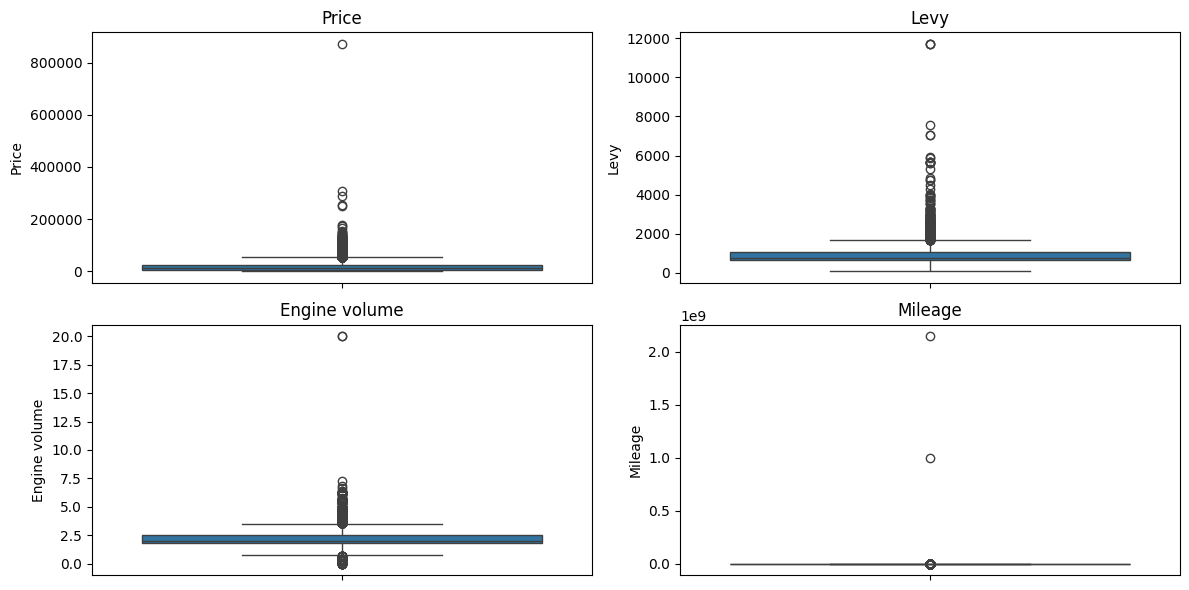

In [200]:
num_cols = ["Price","Levy","Engine volume","Mileage"]

plt.figure(figsize=(12,6))
for i,col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=car_df[col])
    plt.title(col)

plt.tight_layout()

**Price**

- Most car prices are low to medium range.

- Some very expensive cars appear as outliers.

**Levy**

- Most levy values are below 2000

- Few cars have very high levy values, which appear as outliers.

**Engine Volume**

- Most cars have engine volume around 1.5 – 3.5 liters.

- Some cars show very large engine volumes, which are outliers.

**Mileage**

- Most cars have normal mileage values.

- Some values are extremely large (outliers), which may be data errors.

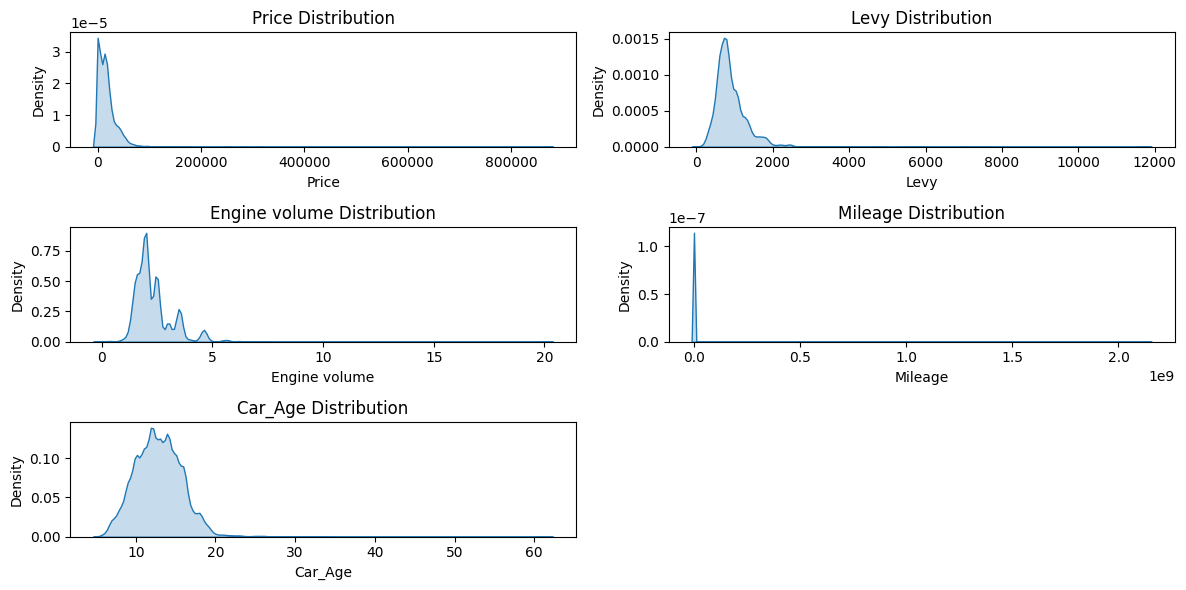

In [201]:
num_cols = ["Price","Levy","Engine volume","Mileage","Car_Age"]

plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols):
    plt.subplot(3,2,i+1)
    sns.kdeplot(car_df[col], fill=True)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

**Price Distribution**

- Most car prices are in the lower range.

- The distribution is right-skewed (few very expensive cars).

- High price values are rare outliers.

**Levy Distribution**

- Most levy values are around 500–1500.

- The distribution is right-skewed.

- A few cars have very high levy values.

**Engine Volume Distribution**

- Most cars have engine volumes between 1.5 and 3.5 liters.

- Large engines above 5 liters are rare.

**Mileage Distribution**

- Most mileage values are very close to lower range.

- Some extremely large mileage values appear, indicating possible data errors or outliers.

**Car Age Distribution**

- Most cars are 10–15 years old.

- Very old cars are rare in the dataset.z

In [202]:
num_cols = ['Price','Levy','Engine volume','Mileage']

for col in num_cols:
    Q1 = car_df[col].quantile(0.25)
    Q3 = car_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    car_df[col] = car_df[col].clip(lower, upper)


- **I handled outliers using IQR-based capping on continuous numerical features like Price, Levy, Engine Volume, and Mileage. This reduced extreme skewness without removing data points.**

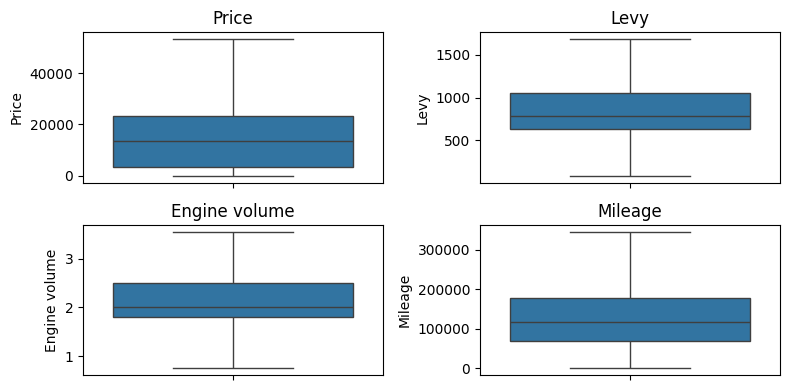

In [207]:
num_cols = ["Price","Levy","Engine volume","Mileage"]

plt.figure(figsize=(8,4))
for i,col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=car_df[col])
    plt.title(col)

plt.tight_layout()

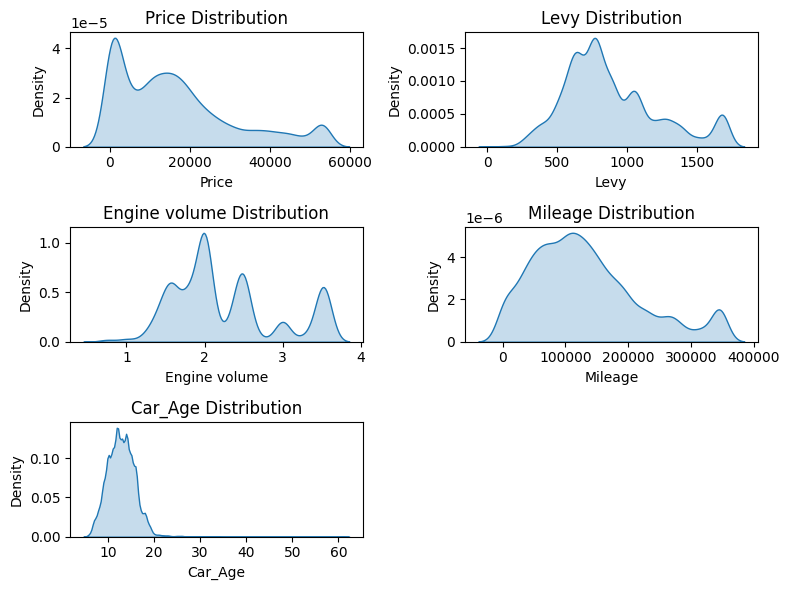

In [205]:
num_cols = ["Price","Levy","Engine volume","Mileage","Car_Age"]

plt.figure(figsize=(8,6))

for i, col in enumerate(num_cols):
    plt.subplot(3,2,i+1)
    sns.kdeplot(car_df[col], fill=True)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

**--> Price: Extreme values reduced → distribution becomes more balanced.**

**--> Levy: High levy outliers controlled.**

**--> Engine Volume: Extreme engine values reduced.**

**--> Mileage: Unrealistic huge mileage values removed.**

**--> Car Age: Distribution remains mostly the same (already reasonable).**

## step 4 :selecting Target variable and Predictors

In [208]:
y = car_df["Price"]
X = car_df.drop(columns="Price")

X.shape, y.shape

((13418, 13), (13418,))

## step 5 :Splitting the data

In [209]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9392, 13), (4026, 13), (9392,), (4026,))

- **I used a 70:30 train–test split because the dataset size is moderate (~13–14k rows). 70% data is sufficient for the model to learn meaningful patterns, while 30% provides enough unseen data for reliable evaluation. This balance helps measure generalization performance and detect overfitting effectively.**

## Step 6:Preprocessing

- **I used Ordinal Encoding because some categorical features had many unique values, and it is more memory-efficient than One-Hot Encoding. It converts categories into numerical form so models can process them easily. I also used handle_unknown = 'use_encoded_value' with unknown_value = -1 to safely handle unseen categories during testing.**
- **I used RobustScaler because the dataset contained significant outliers in features like mileage and levy.**

In [210]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9392 entries, 7994 to 6024
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Levy              9392 non-null   float64
 1   Manufacturer      9392 non-null   object 
 2   Category          9392 non-null   object 
 3   Leather interior  9392 non-null   int64  
 4   Fuel type         9392 non-null   object 
 5   Engine volume     9392 non-null   float64
 6   Mileage           9392 non-null   float64
 7   Cylinders         9392 non-null   float64
 8   Gear box type     9392 non-null   object 
 9   Drive wheels      9392 non-null   object 
 10  Airbags           9392 non-null   int64  
 11  Turbo             9392 non-null   int64  
 12  Car_Age           9392 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 1.0+ MB


In [214]:
X_train["Levy"].nunique(), X_train["Engine volume"].nunique(), X_train["Mileage"].nunique(), X_train["Cylinders"].nunique()

(367, 27, 4872, 12)

In [216]:

trans = ColumnTransformer(transformers=[("t1", RobustScaler(), [0,5,6,12]),
                                       ("t2", OrdinalEncoder(handle_unknown="use_encoded_value",
                                                             unknown_value=-1), [1,2,4,8,9])],
                                                             remainder="passthrough")
X_train_trans = trans.fit_transform(X_train)
X_test_trans = trans.transform(X_test)

type(X_train_trans), type(X_test_trans)

(numpy.ndarray, numpy.ndarray)

**`handle_unknown="use_encoded_value"`, `unknown_value=-1` means if a new unseen category appears in the test data, the encoder will assign it the value `-1` instead of throwing an error.**

In [217]:
# Converting Numpy Array into DataFrame
X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_train.columns)


type(X_train_trans),X_train_trans.shape, type(X_test_trans), X_test_trans.shape

(pandas.core.frame.DataFrame,
 (9392, 13),
 pandas.core.frame.DataFrame,
 (4026, 13))

# Step 7:Model Building


## Decision Tree

In [218]:
dt_model = DecisionTreeRegressor()

dt_model.fit(X_train_trans, y_train)

DecisionTreeRegressor()

In [219]:
# Prediction
DT_y_pred = dt_model.predict(X_test_trans)
DT_X_pred = dt_model.predict(X_train_trans)

In [220]:
# Score
print("Decision Tree Test Data R2 Score : ", r2_score(y_test, DT_y_pred))
print("Decision Tree Train Data R2 Score : ",r2_score(y_train, DT_X_pred))

Decision Tree Test Data R2 Score :  0.6474916158733539
Decision Tree Train Data R2 Score :  0.9841596357929655


In [222]:
dt = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [4, 8, 16, 32],
    "min_samples_leaf": [5, 10, 20, 30],
    "min_samples_split": [20, 50, 100],
    "max_features": ["sqrt", "log2"]
}
grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_trans, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R2 Score:", grid.best_score_)


Best Parameters: {'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV R2 Score: 0.6205751758200427


In [223]:
dt_model = DecisionTreeRegressor(max_depth=16,
                                 min_samples_leaf=5,
                                 min_samples_split=20,
                                 max_features="sqrt",
                                 random_state=42
                               )

dt_model.fit(X_train_trans, y_train)

DecisionTreeRegressor(max_depth=16, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=20, random_state=42)

In [224]:
# Prediction
DT_y_pred = dt_model.predict(X_test_trans)
DT_X_pred = dt_model.predict(X_train_trans)

In [225]:
# Score

print("Decision Tree Test Data R2 Score : ", r2_score(y_test, DT_y_pred))
print("Decision Tree Train Data R2 Score : ",r2_score(y_train, DT_X_pred))
print()
print("Decision Tree Test Data MAE : ", mean_absolute_error(y_test, DT_y_pred))
print("Decision Tree Test Data MSE : ", mean_squared_error(y_test, DT_y_pred))
print("Decision Tree Test Data RMSE : ", root_mean_squared_error(y_test, DT_y_pred))

Decision Tree Test Data R2 Score :  0.6556396792035386
Decision Tree Train Data R2 Score :  0.7676364738968906

Decision Tree Test Data MAE :  5531.045725116572
Decision Tree Test Data MSE :  75293272.4782606
Decision Tree Test Data RMSE :  8677.1696121639


**--> Train R² (0.768) > Test R² (0.656) → The model still has slight overfitting,**

In [226]:

dt_model.feature_importances_

array([0.05189287, 0.07529262, 0.10050821, 0.20340926, 0.05883225,
       0.04587926, 0.11624183, 0.09263113, 0.03081388, 0.02053452,
       0.05335109, 0.14416189, 0.00645118])

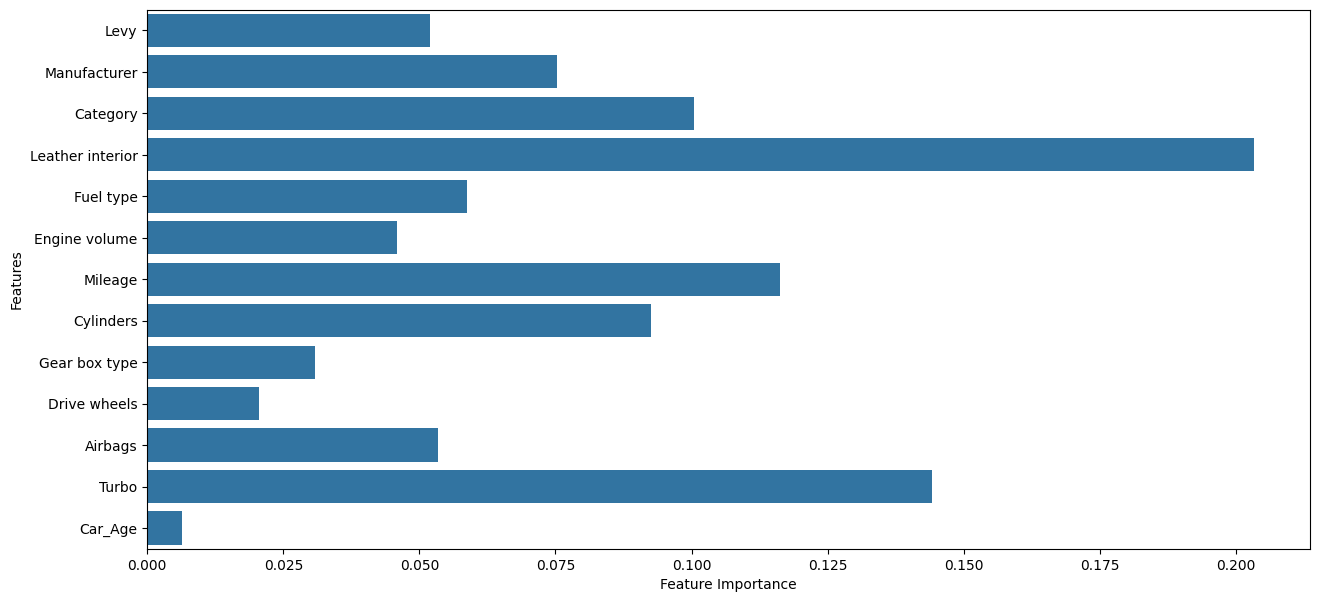

In [227]:
plt.figure(figsize=(15, 7))
sns.barplot(x = dt_model.feature_importances_, y = X_train.columns)
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

## KNN Algoritham

In [228]:

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_trans, y_train)

KNeighborsRegressor()

In [229]:
knn_y_pred = knn_model.predict(X_test_trans)
knn_X_pred = knn_model.predict(X_train_trans)

In [230]:
print("KNN Test Data R2 Score : ", r2_score(y_test, knn_y_pred))
print("KNN Train Data R2 Score : ", r2_score(y_train, knn_X_pred))

KNN Test Data R2 Score :  0.7101529921089013
KNN Train Data R2 Score :  0.8330462483312411


In [232]:

knn_pipe = make_pipeline(trans, KNeighborsRegressor())

tuned_parameters = [{
    "kneighborsregressor__n_neighbors": list(range(1, 51)),
    "kneighborsregressor__p": [1, 2, 3]
}]

knn_search = RandomizedSearchCV(knn_pipe,
                      param_distributions=tuned_parameters,
                      cv = 5,
                      scoring="r2",
                      return_train_score= True
                     )

knn_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('t1',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                5,
                                                                                6,
                                                                                12]),
                                                                              ('t2',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               [1,
                                                                                2,
                                                                                4,
                                                                                8,
                                                                                9])])),
                                             ('kneighborsregressor',
                                              KNeighborsRegressor())]),
                   param_distributions=[{'kneighborsregressor__n_neighbors': [1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                              5,
                                                                              6,
                                                                              7,
                                                                              8,
                                                                              9,
                                                                              10,
                                                                              11,
                                                                              12,
                                                                              13,
                                                                              14,
                                                                              15,
                                                                              16,
                                                                              17,
                                                                              18,
                                                                              19,
                                                                              20,
                                                                              21,
                                                                              22,
                                                                              23,
                                                                              24,
                                                                              25,
                                                                              26,
                                                                              27,
                                                                              28,
                                                                              29,
                                              

In [233]:
print(knn_search.best_params_)
print(knn_search.best_estimator_)

print("Score: ", knn_search.score(X_test, y_test))

{'kneighborsregressor__p': 1, 'kneighborsregressor__n_neighbors': 5}
Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('kneighborsregressor', KNeighborsRegressor(p=1))])
Score:  0.719107183530163


In [234]:

knn_model = KNeighborsRegressor(n_neighbors=5, p=1)
knn_model.fit(X_train_trans, y_train)

KNeighborsRegressor(p=1)

In [235]:
knn_y_pred = knn_model.predict(X_test_trans)
knn_X_pred = knn_model.predict(X_train_trans)

In [238]:
print("KNN Test Data R2 Score : ", r2_score(y_test, knn_y_pred))
print("KNN Train Data R2 Score : ", r2_score(y_train, knn_X_pred))

print("KNN Test Data MAE : ", mean_absolute_error(y_test, knn_y_pred))
print("KNN Test Data MSE : ", mean_squared_error(y_test, knn_y_pred))
print("KNN Test Data RMSE : ", root_mean_squared_error(y_test, knn_y_pred))

KNN Test Data R2 Score :  0.719107183530163
KNN Train Data R2 Score :  0.8391462210582006
KNN Test Data MAE :  4514.142796820665
KNN Test Data MSE :  61416307.54302285
KNN Test Data RMSE :  7836.855717889851


**--> Train R² > Test R² → Indicates slight overfitting, but still acceptable.**

**--> Compared to the Decision Tree (R² ≈ 0.656), KNN performs better on the test data.**

## Random Forest

In [237]:
# Model
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 8, 16, 32],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt", "log2"]
}

# Grid Search
grid_rf = RandomizedSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit
grid_rf.fit(X_train_trans, y_train)

# Results
print("Best Parameters:", grid_rf.best_params_)
print("Best CV R2 Score:", grid_rf.best_score_)


Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 16}
Best CV R2 Score: 0.7020233885508095


In [239]:
# Random Forest
RFR_model =make_pipeline(trans, RandomForestRegressor(max_depth=16,
                                  n_estimators=300,
                                  min_samples_leaf=5,
                                  min_samples_split=10,
                                  max_features="sqrt"))


RFR_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=16, max_features='sqrt',
                                       min_samples_leaf=5, min_samples_split=10,
                                       n_estimators=300))])

In [240]:
RF_y_pred = RFR_model.predict(X_test)
RF_X_pred = RFR_model.predict(X_train)

In [241]:
print("Random Forest Test Data R2 Score : ", r2_score(y_test, RF_y_pred))
print("Random Forest Train Data R2 Score : ", r2_score(y_train, RF_X_pred))
print()
print("Random Forest Test Data MAE : ", mean_absolute_error(y_test, RF_y_pred))
print("Random Forest Test Data MSE : ", mean_squared_error(y_test, RF_y_pred))
print("Random Forest Test Data RMSE : ", root_mean_squared_error(y_test, RF_y_pred))

Random Forest Test Data R2 Score :  0.7428428794174249
Random Forest Train Data R2 Score :  0.8141437679886506

Random Forest Test Data MAE :  5051.676592314647
Random Forest Test Data MSE :  56226574.2608395
Random Forest Test Data RMSE :  7498.438121424988


**--> Random Forest (R² ≈ 0.74) performs better than Decision Tree (≈0.65) and slightly better than KNN (≈0.72).**

## Linear Regression

In [244]:
LR_pipe = make_pipeline(trans, LinearRegression())
LR_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('linearregression', LinearRegression())])

In [245]:
LR_y_pred = LR_pipe.predict(X_test)
print(y_test.shape, LR_y_pred.shape)

LR_X_pred = LR_pipe.predict(X_train)
print(y_train.shape, LR_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [246]:
print("Linear Regression Test Data R2 Score : ", r2_score(y_test, LR_y_pred))
print("Linear Regression Train Data R2 Score : ", r2_score(y_train, LR_X_pred))
print()
print("Linear Regression Test Data MAE : ", mean_absolute_error(y_test, LR_y_pred))
print("Linear Regression Test Data MSE : ", mean_squared_error(y_test, LR_y_pred))
print("Linear Regression Test Data RMSE : ", root_mean_squared_error(y_test, LR_y_pred))

Linear Regression Test Data R2 Score :  0.2975189953059837
Linear Regression Train Data R2 Score :  0.2912427446785363

Linear Regression Test Data MAE :  9708.849414724566
Linear Regression Test Data MSE :  153595203.9273752
Linear Regression Test Data RMSE :  12393.353215630352


**--> Train R² ≈ 0.29 and Test R² ≈ 0.30 → Both scores are similar, meaning no overfitting, but the model cannot capture complex relationships**

## Lasso

In [247]:
Lasso_pipe = make_pipeline(trans, Lasso())
Lasso_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('lasso', Lasso())])

In [248]:
lasso_y_pred = Lasso_pipe.predict(X_test)
print(y_test.shape, lasso_y_pred.shape)

lasso_X_pred = Lasso_pipe.predict(X_train)
print(y_train.shape, lasso_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [249]:
print("Lasso Test Data R2 Score : ", r2_score(y_test, lasso_y_pred))
print("Lasso Train Data R2 Score : ", r2_score(y_train, lasso_X_pred))
print()
print("Lasso Test Data MAE : ", mean_absolute_error(y_test, lasso_y_pred))
print("Lasso Test Data MSE : ", mean_squared_error(y_test, lasso_y_pred))
print("Lasso Test Data RMSE : ", root_mean_squared_error(y_test, lasso_y_pred))

Lasso Test Data R2 Score :  0.2975073540085609
Lasso Train Data R2 Score :  0.291242491894805

Lasso Test Data MAE :  9708.854853306935
Lasso Test Data MSE :  153597749.25947627
Lasso Test Data RMSE :  12393.45590460854


**--> Train R² ≈ 0.291 and Test R² ≈ 0.297 → Very close values, meaning no overfitting, but the model underfits the data.**

## RIDGE

In [250]:
Ridge_pipe = make_pipeline(trans, Ridge())
Ridge_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('ridge', Ridge())])

In [251]:
ridge_y_pred = Ridge_pipe.predict(X_test)
print(y_test.shape, ridge_y_pred.shape)

ridge_X_pred = Ridge_pipe.predict(X_train)
print(y_train.shape, ridge_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [252]:
print("Ridge Test Data R2 Score : ", r2_score(y_test, ridge_y_pred))
print("Ridge Train Data R2 Score : ", r2_score(y_train, ridge_X_pred))
print()
print("Ridge Test Data MAE : ", mean_absolute_error(y_test, ridge_y_pred))
print("Ridge Test Data MSE : ", mean_squared_error(y_test, ridge_y_pred))
print("Ridge Test Data RMSE : ", root_mean_squared_error(y_test, ridge_y_pred))

Ridge Test Data R2 Score :  0.29751861905216814
Ridge Train Data R2 Score :  0.2912426704877822

Ridge Test Data MAE :  9708.758441998956
Ridge Test Data MSE :  153595286.19405735
Ridge Test Data RMSE :  12393.356534613911


**--> Train R² ≈ 0.291 and Test R² ≈ 0.297 → Both values are very close, indicating no overfitting, but the model underfits the data.**

## Elastic Net

In [253]:
EN_pipe = make_pipeline(trans, ElasticNet())
EN_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('elasticnet', ElasticNet())])

In [254]:
en_y_pred = EN_pipe.predict(X_test)
print(y_test.shape, en_y_pred.shape)

en_X_pred = EN_pipe.predict(X_train)
print(y_train.shape, en_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [255]:
print("Elastic Net Test Data R2 Score : ", r2_score(y_test, en_y_pred))
print("Elastic Net Train Data R2 Score : ", r2_score(y_train, en_X_pred))
print()
print("Elastic Net Test Data MAE : ", mean_absolute_error(y_test, en_y_pred))
print("Elastic Net Test Data MSE : ", mean_squared_error(y_test, en_y_pred))
print("Elastic Net Test Data RMSE : ", root_mean_squared_error(y_test, en_y_pred))

Elastic Net Test Data R2 Score :  0.23492329311523108
Elastic Net Train Data R2 Score :  0.22978366880209122

Elastic Net Test Data MAE :  10125.322605966034
Elastic Net Test Data MSE :  167281552.13995597
Elastic Net Test Data RMSE :  12933.736975056976


**--> Train R² ≈ 0.229 and Test R² ≈ 0.235 → Both values are similar, indicating no overfitting but strong underfitting.**

## Ensembles
## Voting Ensemble

In [262]:
Voting_pipe = make_pipeline(trans, VotingRegressor(estimators=[("KNN",KNeighborsRegressor()),("DT",DecisionTreeRegressor()),
                                                         ("LR",LinearRegression()),("RF",RandomForestRegressor())]))
Voting_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('votingregressor',
                 VotingRegressor(estimators=[('KNN', KNeighborsRegressor()),
                                             ('DT', DecisionTreeRegressor()),
                                             ('LR', LinearRegression()),
                                             ('RF',
                                              RandomForestRegressor())]))])

In [263]:
vote_y_pred = Voting_pipe.predict(X_test)
print(y_test.shape, vote_y_pred.shape)

vote_X_pred = Voting_pipe.predict(X_train)
print(y_train.shape, vote_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [264]:
print("Voting Ensemble Test Data R2 Score : ", r2_score(y_test, vote_y_pred))
print("Voting Ensemble Train Data R2 Score : ", r2_score(y_train, vote_X_pred))
print()
print("Voting Ensemble Data MAE : ", mean_absolute_error(y_test, vote_y_pred))
print("Voting Ensemble Test Data MSE : ", mean_squared_error(y_test, vote_y_pred))
print("Voting Ensemble Test Data RMSE : ", root_mean_squared_error(y_test, vote_y_pred))

Voting Ensemble Test Data R2 Score :  0.7550420325206556
Voting Ensemble Train Data R2 Score :  0.9018093309336079

Voting Ensemble Data MAE :  4857.437595522511
Voting Ensemble Test Data MSE :  53559268.816120535
Voting Ensemble Test Data RMSE :  7318.419830545426


**--> Train R² > Test R² → Indicates some overfitting, but ensemble models generally perform better.**<br>
**--> Voting Ensemble combines predictions from KNN, Decision Tree, Linear Regression, and Random Forest, which improves overall prediction accuracy.**

## Stacking Ensemble

In [265]:
Stack_pipe = make_pipeline(trans, StackingRegressor(estimators=[("KNN",KNeighborsRegressor()),("DT",DecisionTreeRegressor()),
                                                         ("LR",LinearRegression())],
                                                    final_estimator=RandomForestRegressor()))
Stack_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('stackingregressor',
                 StackingRegressor(estimators=[('KNN', KNeighborsRegressor()),
                                               ('DT', DecisionTreeRegressor()),
                                               ('LR', LinearRegression())],
                                   final_estimator=RandomForestRegressor()))])

In [266]:
stack_y_pred = Stack_pipe.predict(X_test)
print(y_test.shape, stack_y_pred.shape)

stack_X_pred = Stack_pipe.predict(X_train)
print(y_train.shape, stack_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [267]:
print("Stacking Ensemble Test Data R2 Score : ", r2_score(y_test, stack_y_pred))
print("Stacking Ensemble Train Data R2 Score : ", r2_score(y_train, stack_X_pred))
print()
print("Stacking Ensemble Test Data MAE : ", mean_absolute_error(y_test, stack_y_pred))
print("Stacking Ensemble Test Data MSE : ", mean_squared_error(y_test, stack_y_pred))
print("Stacking Ensemble Test Data RMSE : ", root_mean_squared_error(y_test, stack_y_pred))

Stacking Ensemble Test Data R2 Score :  0.7350285213677588
Stacking Ensemble Train Data R2 Score :  0.8947602080390836

Stacking Ensemble Test Data MAE :  4469.054708448417
Stacking Ensemble Test Data MSE :  57935158.42209066
Stacking Ensemble Test Data RMSE :  7611.514857246923


**--> Train R² > Test R² → Indicates some overfitting, which is common in ensemble models.**

**--> The stacking model combines predictions from KNN, Decision Tree, and Linear Regression, and then uses Random Forest as the final estimator, improving overall predictive performance.**

## Boosting Ensembles
## Adaptive Boosting

In [268]:
base_estimator= DecisionTreeRegressor(random_state=42)
ADA_pipe=make_pipeline(trans,AdaBoostRegressor(estimator=base_estimator, random_state=42))

In [269]:
param_dist = {
    'adaboostregressor__n_estimators': [50, 100, 150, 200, 300],
    'adaboostregressor__learning_rate': [0.001, 0.01, 0.1],
    'adaboostregressor__estimator__max_depth': [2,4, 8, 16, 32]
}

ADA_random_search = RandomizedSearchCV(
    ADA_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

ADA_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('t1',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                5,
                                                                                6,
                                                                                12]),
                                                                              ('t2',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               [1,
                                                                                2,
                                                                                4,
                                                                                8,
                                                                                9])])),
                                             ('adaboostregressor',
                                              AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=42),
                                                                random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'adaboostregressor__estimator__max_depth': [2,
                                                                                    4,
                                                                                    8,
                                                                                    16,
                                                                                    32],
                                        'adaboostregressor__learning_rate': [0.001,
                                                                             0.01,
                                                                             0.1],
                                        'adaboostregressor__n_estimators': [50,
                                                                            100,
                                                                            150,
                                                                            200,
                                                                            300]},
                   random_state=42, scoring='r2')

In [270]:
print("Best Parameters:", ADA_random_search.best_params_)

Best Parameters: {'adaboostregressor__n_estimators': 100, 'adaboostregressor__learning_rate': 0.1, 'adaboostregressor__estimator__max_depth': 16}


In [271]:
base_estimator= DecisionTreeRegressor(max_depth=16)
ADA_pipe=make_pipeline(trans,AdaBoostRegressor(estimator=base_estimator, n_estimators=100, learning_rate=0.1))
ADA_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('adaboostregressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=16),
                                   learning_rate=0.1, n_estimators=100))])

In [272]:
adap_y_pred = ADA_pipe.predict(X_test)
print(y_test.shape, adap_y_pred.shape)

adap_X_pred = ADA_pipe.predict(X_train)
print(y_train.shape, adap_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [273]:
print("Adaptive Boosting Test Data R2 Score : ", r2_score(y_test, adap_y_pred))
print("Adaptive Boosting Train Data R2 Score : ", r2_score(y_train, adap_X_pred))
print()
print("Adaptive Boosting Test Data MAE : ", mean_absolute_error(y_test, adap_y_pred))
print("Adaptive Boosting Test Data MSE : ", mean_squared_error(y_test, adap_y_pred))
print("Adaptive Boosting Test Data RMSE : ", root_mean_squared_error(y_test, adap_y_pred))

Adaptive Boosting Test Data R2 Score :  0.7794749227558773
Adaptive Boosting Train Data R2 Score :  0.969108300709119

Adaptive Boosting Test Data MAE :  3712.610325407152
Adaptive Boosting Test Data MSE :  48217096.24043834
Adaptive Boosting Test Data RMSE :  6943.853126358473


**--> AdaBoost improves performance by combining multiple weak learners (Decision Trees) and focusing more on previous prediction errors, which increases overall model accuracy.**

## Gradient Boosting

In [274]:
Grad_pipe=make_pipeline(trans,GradientBoostingRegressor(random_state=42))

In [276]:
param_dist = {
    'gradientboostingregressor__n_estimators': [50, 100, 150, 200, 300],
    'gradientboostingregressor__learning_rate': [0.01, 0.001, 0.1],
    'gradientboostingregressor__max_depth': [2, 4, 8, 16, 32],
    'gradientboostingregressor__subsample': [0.6, 0.8, 1.0]
}

Grad_random_search = RandomizedSearchCV(
    Grad_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

Grad_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('t1',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                5,
                                                                                6,
                                                                                12]),
                                                                              ('t2',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               [1,
                                                                                2,
                                                                                4,
                                                                                8,
                                                                                9])])),
                                             ('gradientboostingregressor',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'gradientboostingregressor__learning_rate': [0.01,
                                                                                     0.001,
                                                                                     0.1],
                                        'gradientboostingregressor__max_depth': [2,
                                                                                 4,
                                                                                 8,
                                                                                 16,
                                                                                 32],
                                        'gradientboostingregressor__n_estimators': [50,
                                                                                    100,
                                                                                    150,
                                                                                    200,
                                                                                    300],
                                        'gradientboostingregressor__subsample': [0.6,
                                                                                 0.8,
                                                                                 1.0]},
                   random_state=42, scoring='r2')

In [277]:
print("Best Parameters:", Grad_random_search.best_params_)

Best Parameters: {'gradientboostingregressor__subsample': 0.8, 'gradientboostingregressor__n_estimators': 100, 'gradientboostingregressor__max_depth': 8, 'gradientboostingregressor__learning_rate': 0.1}


In [278]:
Grad_pipe=make_pipeline(trans,GradientBoostingRegressor(subsample=0.8, n_estimators=100, max_depth=8, learning_rate=0.1))
Grad_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_depth=8, subsample=0.8))])

In [279]:
grad_y_pred = Grad_pipe.predict(X_test)
print(y_test.shape, grad_y_pred.shape)

grad_X_pred = Grad_pipe.predict(X_train)
print(y_train.shape, grad_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [280]:
print("Gradient Boosting Test Data R2 Score : ", r2_score(y_test, grad_y_pred))
print("Gradient Boosting Train Data R2 Score : ", r2_score(y_train, grad_X_pred))
print()
print("Gradient Boosting Test Data MAE : ", mean_absolute_error(y_test, grad_y_pred))
print("Gradient Boosting Test Data MSE : ", mean_squared_error(y_test, grad_y_pred))
print("Gradient Boosting Test Data RMSE : ", root_mean_squared_error(y_test, grad_y_pred))

Gradient Boosting Test Data R2 Score :  0.7943516306375854
Gradient Boosting Train Data R2 Score :  0.9320910144857122

Gradient Boosting Test Data MAE :  4175.671858670368
Gradient Boosting Test Data MSE :  44964352.08708684
Gradient Boosting Test Data RMSE :  6705.546367529409


**--> Train R² > Test R² → Indicates some overfitting, but the model still generalizes well.**

**--> Gradient Boosting improves prediction accuracy by sequentially correcting errors of previous models, making it very effective for complex datasets.**

## XG Boosting

In [281]:
import xgboost as xgb


In [282]:
XG_pipe = make_pipeline(trans, xgb.XGBRegressor())
XG_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [284]:
xgb_y_pred = XG_pipe.predict(X_test)
print(y_test.shape, xgb_y_pred.shape)

xgb_X_pred = XG_pipe.predict(X_train)
print(y_train.shape, xgb_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [285]:
print("XG Boosting Test Data R2 Score : ", r2_score(y_test, xgb_y_pred))
print("XG Boosting Train Data R2 Score : ", r2_score(y_train, xgb_X_pred))
print()
print("XG Boosting Test Data MAE : ", mean_absolute_error(y_test, xgb_y_pred))
print("XG Boosting Test Data MSE : ", mean_squared_error(y_test, xgb_y_pred))
print("XG Boosting Test Data RMSE : ", root_mean_squared_error(y_test, xgb_y_pred))

XG Boosting Test Data R2 Score :  0.7870615965003824
XG Boosting Train Data R2 Score :  0.9137581017647906

XG Boosting Test Data MAE :  4241.127244044464
XG Boosting Test Data MSE :  46558294.51750021
XG Boosting Test Data RMSE :  6823.363871104941


**--> Train R² > Test R² → Indicates some overfitting, but the model still generalizes well.**

**--> XGBoost achieved very high accuracy (R² ≈ 0.79), performing almost equal to Gradient Boosting and among the best models for car price prediction.**

In [286]:
scores_df = {"Algorithm" : ["KNN","Decision Tree","Linear Regression","Lasso","Ridge","Elastic Net","Voting Ensemble",
                  "Stacking Ensemble","Random Forest","Adaptive Boosting","Gradient Boosting", "XG Boosting"],
   "Test Score" : [r2_score(y_test, knn_y_pred),r2_score(y_test, DT_y_pred),r2_score(y_test, LR_y_pred),
                   r2_score(y_test, lasso_y_pred),r2_score(y_test,ridge_y_pred),r2_score(y_test,en_y_pred),
                  r2_score(y_test,vote_y_pred),r2_score(y_test,stack_y_pred),r2_score(y_test,RF_y_pred),
                  r2_score(y_test,adap_y_pred),r2_score(y_test,grad_y_pred), r2_score(y_test, xgb_y_pred)],

    "Train Score" : [r2_score(y_train, knn_X_pred), r2_score(y_train, DT_X_pred), r2_score(y_train, LR_X_pred),
                     r2_score(y_train, lasso_X_pred),r2_score(y_train, ridge_X_pred), r2_score(y_train, en_X_pred),
                     r2_score(y_train,vote_X_pred),r2_score(y_train,stack_X_pred), r2_score(y_train,RF_X_pred),
                     r2_score(y_train,adap_X_pred),r2_score(y_train,grad_X_pred), r2_score(y_train, xgb_X_pred)],
    "MAE" : [mean_absolute_error(y_test, knn_y_pred),mean_absolute_error(y_test, DT_y_pred),mean_absolute_error(y_test, LR_y_pred),
             mean_absolute_error(y_test, lasso_y_pred),mean_absolute_error(y_test,ridge_y_pred),mean_absolute_error(y_test,en_y_pred),
             mean_absolute_error(y_test,vote_y_pred),mean_absolute_error(y_test,stack_y_pred),mean_absolute_error(y_test,RF_y_pred),
             mean_absolute_error(y_test,adap_y_pred),mean_absolute_error(y_test,grad_y_pred), mean_absolute_error(y_test, xgb_y_pred)],

    "MSE" : [mean_squared_error(y_test, knn_y_pred),mean_squared_error(y_test, DT_y_pred),mean_squared_error(y_test, LR_y_pred),
             mean_squared_error(y_test, lasso_y_pred),mean_squared_error(y_test,ridge_y_pred),mean_squared_error(y_test,en_y_pred),
             mean_squared_error(y_test,vote_y_pred),mean_squared_error(y_test,stack_y_pred),mean_squared_error(y_test,RF_y_pred),
             mean_squared_error(y_test,adap_y_pred),mean_squared_error(y_test,grad_y_pred), mean_squared_error(y_test, xgb_y_pred)],

    "RMSE" : [root_mean_squared_error(y_test, knn_y_pred),root_mean_squared_error(y_test, DT_y_pred),root_mean_squared_error(y_test, LR_y_pred),
              root_mean_squared_error(y_test, lasso_y_pred),root_mean_squared_error(y_test,ridge_y_pred),root_mean_squared_error(y_test,en_y_pred),
              root_mean_squared_error(y_test,vote_y_pred),root_mean_squared_error(y_test,stack_y_pred),root_mean_squared_error(y_test,RF_y_pred),
              root_mean_squared_error(y_test,adap_y_pred),root_mean_squared_error(y_test,grad_y_pred), root_mean_squared_error(y_test, xgb_y_pred)]}
pd.DataFrame(scores_df)

,Algorithm,Test Score,Train Score,MAE,MSE,RMSE
0,KNN,0.719107,0.839146,4514.142797,6.141631e+07,7836.855718
1,Decision Tree,0.655640,0.767636,5531.045725,7.529327e+07,8677.169612
2,Linear Regression,0.297519,0.291243,9708.849415,1.535952e+08,12393.353216
3,Lasso,0.297507,0.291242,9708.854853,1.535977e+08,12393.455905
4,Ridge,0.297519,0.291243,9708.758442,1.535953e+08,12393.356535
5,Elastic Net,0.234923,0.229784,10125.322606,1.672816e+08,12933.736975
6,Voting Ensemble,0.755042,0.901809,4857.437596,5.355927e+07,7318.419831
7,Stacking Ensemble,0.735029,0.894760,4469.054708,5.793516e+07,7611.514857
8,Random Forest,0.742843,0.814144,5051.676592,5.622657e+07,7498.438121
9,Adaptive Boosting,0.779475,0.969108,3712.610325,4.821710e+07,6943.853126


- **Boosting algorithms performed best for this dataset.**

- **Gradient Boosting achieved the highest accuracy and lowest RMSE, making it the final selected model for car price prediction.**

In [287]:
with open("car_price_pipeline(GD).pkl", "wb") as f:
    pickle.dump(Grad_pipe, f)

In [288]:
with open("car_price_pipeline(GD).pkl", "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 4, 8, 9])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_depth=8, subsample=0.8))])

In [ ]:
import sklearn
print(sklearn.__version__)


1.5.1


In [ ]:
with open("car_price_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [ ]:
with open("car_price_pipeline.pkl", "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 3, 4, 8, 9])])),
                ('model',
                 RandomForestRegressor(max_features=None, min_samples_leaf=5,
                                       min_samples_split=20, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [ ]:
import sys
print(sys.version)


3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
